In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

**Data Exploration**

In [2]:
df = pd.read_excel('data/online_retail_II.xlsx', sheet_name=0)

In [3]:
df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 525461 entries, 0 to 525460
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   Invoice      525461 non-null  object        
 1   StockCode    525461 non-null  object        
 2   Description  522533 non-null  object        
 3   Quantity     525461 non-null  int64         
 4   InvoiceDate  525461 non-null  datetime64[ns]
 5   Price        525461 non-null  float64       
 6   Customer ID  417534 non-null  float64       
 7   Country      525461 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 32.1+ MB


In [5]:
df.isna().sum()

Invoice             0
StockCode           0
Description      2928
Quantity            0
InvoiceDate         0
Price               0
Customer ID    107927
Country             0
dtype: int64

In [6]:
df.describe()

,Quantity,InvoiceDate,Price,Customer ID
count,525461.000000,525461,525461.000000,417534.000000
mean,10.337667,2010-06-28 11:37:36.845017856,4.688834,15360.645478
min,-9600.000000,2009-12-01 07:45:00,-53594.360000,12346.000000
25%,1.000000,2010-03-21 12:20:00,1.250000,13983.000000
50%,3.000000,2010-07-06 09:51:00,2.100000,15311.000000
75%,10.000000,2010-10-15 12:45:00,4.210000,16799.000000
max,19152.000000,2010-12-09 20:01:00,25111.090000,18287.000000
std,107.424110,NaN,146.126914,1680.811316


In [7]:
df.describe(include='O')

,Invoice,StockCode,Description,Country
count,525461,525461,522533,525461
unique,28816,4632,4681,40
top,537434,85123A,WHITE HANGING HEART T-LIGHT HOLDER,United Kingdom
freq,675,3516,3549,485852


In [8]:
df[df['Customer ID'].isna()].head(10)

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
263,489464,21733,85123a mixed,-96,2009-12-01 10:52:00,0.00,NaN,United Kingdom
283,489463,71477,short,-240,2009-12-01 10:52:00,0.00,NaN,United Kingdom
284,489467,85123A,21733 mixed,-192,2009-12-01 10:53:00,0.00,NaN,United Kingdom
470,489521,21646,NaN,-50,2009-12-01 11:44:00,0.00,NaN,United Kingdom
577,489525,85226C,BLUE PULL BACK RACING CAR,1,2009-12-01 11:49:00,0.55,NaN,United Kingdom
578,489525,85227,SET/6 3D KIT CARDS FOR KIDS,1,2009-12-01 11:49:00,0.85,NaN,United Kingdom
1055,489548,22271,FELTCRAFT DOLL ROSIE,1,2009-12-01 12:32:00,2.95,NaN,United Kingdom
1056,489548,22254,FELT TOADSTOOL LARGE,12,2009-12-01 12:32:00,1.25,NaN,United Kingdom
1057,489548,22273,FELTCRAFT DOLL MOLLY,3,2009-12-01 12:32:00,2.95,NaN,United Kingdom
1058,489548,22195,LARGE HEART MEASURING SPOONS,1,2009-12-01 12:32:00,1.65,NaN,United Kingdom


In [9]:
df[df['Quantity'] < 0].head(10)

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
178,C489449,22087,PAPER BUNTING WHITE LACE,-12,2009-12-01 10:33:00,2.95,16321.0,Australia
179,C489449,85206A,CREAM FELT EASTER EGG BASKET,-6,2009-12-01 10:33:00,1.65,16321.0,Australia
180,C489449,21895,POTTING SHED SOW 'N' GROW SET,-4,2009-12-01 10:33:00,4.25,16321.0,Australia
181,C489449,21896,POTTING SHED TWINE,-6,2009-12-01 10:33:00,2.10,16321.0,Australia
182,C489449,22083,PAPER CHAIN KIT RETRO SPOT,-12,2009-12-01 10:33:00,2.95,16321.0,Australia
183,C489449,21871,SAVE THE PLANET MUG,-12,2009-12-01 10:33:00,1.25,16321.0,Australia
184,C489449,84946,ANTIQUE SILVER TEA GLASS ETCHED,-12,2009-12-01 10:33:00,1.25,16321.0,Australia
185,C489449,84970S,HANGING HEART ZINC T-LIGHT HOLDER,-24,2009-12-01 10:33:00,0.85,16321.0,Australia
186,C489449,22090,PAPER BUNTING RETRO SPOTS,-12,2009-12-01 10:33:00,2.95,16321.0,Australia
196,C489459,90200A,PURPLE SWEETHEART BRACELET,-3,2009-12-01 10:44:00,4.25,17592.0,United Kingdom


In [10]:
df['Invoice'] = df['Invoice'].astype(str)
df[df['Invoice'].str.match(r'^\d{6}$') == True]

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom
...,...,...,...,...,...,...,...,...
525456,538171,22271,FELTCRAFT DOLL ROSIE,2,2010-12-09 20:01:00,2.95,17530.0,United Kingdom
525457,538171,22750,FELTCRAFT PRINCESS LOLA DOLL,1,2010-12-09 20:01:00,3.75,17530.0,United Kingdom
525458,538171,22751,FELTCRAFT PRINCESS OLIVIA DOLL,1,2010-12-09 20:01:00,3.75,17530.0,United Kingdom
525459,538171,20970,PINK FLORAL FELTCRAFT SHOULDER BAG,2,2010-12-09 20:01:00,3.75,17530.0,United Kingdom


In [11]:
df['Invoice'].str.replace("[0-9]", "", regex=True).str.strip().unique()

array(['', 'C', 'A'], dtype=object)

In [12]:
df[df['Invoice'].str.startswith('A') == True]

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
179403,A506401,B,Adjust bad debt,1,2010-04-29 13:36:00,-53594.36,NaN,United Kingdom
276274,A516228,B,Adjust bad debt,1,2010-07-19 11:24:00,-44031.79,NaN,United Kingdom
403472,A528059,B,Adjust bad debt,1,2010-10-20 12:04:00,-38925.87,NaN,United Kingdom


In [13]:
df['StockCode'] = df['StockCode'].astype(str)
df[(df['StockCode'].str.match(r'^\d{5}$') == False) & (df['StockCode'].str.match(r'^\d{5}[a-zA-Z]+$') == False)]['StockCode'].unique()

array(['POST', 'D', 'DCGS0058', 'DCGS0068', 'DOT', 'M', 'DCGS0004',
       'DCGS0076', 'C2', 'BANK CHARGES', 'DCGS0003', 'TEST001',
       'gift_0001_80', 'DCGS0072', 'gift_0001_20', 'DCGS0044', 'TEST002',
       'gift_0001_10', 'gift_0001_50', 'DCGS0066N', 'gift_0001_30',
       'PADS', 'ADJUST', 'gift_0001_40', 'gift_0001_60', 'gift_0001_70',
       'gift_0001_90', 'DCGSSGIRL', 'DCGS0006', 'DCGS0016', 'DCGS0027',
       'DCGS0036', 'DCGS0039', 'DCGS0060', 'DCGS0056', 'DCGS0059', 'GIFT',
       'DCGSLBOY', 'm', 'DCGS0053', 'DCGS0062', 'DCGS0037', 'DCGSSBOY',
       'DCGSLGIRL', 'S', 'DCGS0069', 'DCGS0070', 'DCGS0075', 'B',
       'DCGS0041', 'ADJUST2', '47503J ', 'C3', 'SP1002', 'AMAZONFEE'],
      dtype=object)

**Data Cleaning**

In [14]:
cleaned_df = df.copy()

In [15]:
cleaned_df['Invoice'] = cleaned_df['Invoice'].astype(str)
mask = (
    cleaned_df['Invoice'].str.match(r'^\d{6}$') == True
)

cleaned_df = cleaned_df[mask]
cleaned_df

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom
...,...,...,...,...,...,...,...,...
525456,538171,22271,FELTCRAFT DOLL ROSIE,2,2010-12-09 20:01:00,2.95,17530.0,United Kingdom
525457,538171,22750,FELTCRAFT PRINCESS LOLA DOLL,1,2010-12-09 20:01:00,3.75,17530.0,United Kingdom
525458,538171,22751,FELTCRAFT PRINCESS OLIVIA DOLL,1,2010-12-09 20:01:00,3.75,17530.0,United Kingdom
525459,538171,20970,PINK FLORAL FELTCRAFT SHOULDER BAG,2,2010-12-09 20:01:00,3.75,17530.0,United Kingdom


In [16]:
cleaned_df['StockCode'] = cleaned_df['StockCode'].astype(str)
mask = (
    (cleaned_df['StockCode'].str.match(r'^\d{5}$') == True)
    |(cleaned_df['StockCode'].str.match(r'^\d{5}[a-zA-Z]+$') == True)
    # |(cleaned_df['StockCode'].str.match(r'^PADS$') == True)
)

cleaned_df = cleaned_df[mask]
cleaned_df

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom
...,...,...,...,...,...,...,...,...
525456,538171,22271,FELTCRAFT DOLL ROSIE,2,2010-12-09 20:01:00,2.95,17530.0,United Kingdom
525457,538171,22750,FELTCRAFT PRINCESS LOLA DOLL,1,2010-12-09 20:01:00,3.75,17530.0,United Kingdom
525458,538171,22751,FELTCRAFT PRINCESS OLIVIA DOLL,1,2010-12-09 20:01:00,3.75,17530.0,United Kingdom
525459,538171,20970,PINK FLORAL FELTCRAFT SHOULDER BAG,2,2010-12-09 20:01:00,3.75,17530.0,United Kingdom


In [17]:
cleaned_df.dropna(subset=['Customer ID'], inplace=True)

C:\Users\ASUS\AppData\Local\Temp\ipykernel_11476\376660035.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  cleaned_df.dropna(subset=['Customer ID'], inplace=True)


In [18]:
cleaned_df.describe()

,Quantity,InvoiceDate,Price,Customer ID
count,406323.000000,406323,406323.000000,406323.000000
mean,13.619534,2010-07-01 10:14:46.649094656,2.991565,15373.660913
min,1.000000,2009-12-01 07:45:00,0.000000,12346.000000
25%,2.000000,2010-03-26 14:01:00,1.250000,14004.000000
50%,5.000000,2010-07-09 15:48:00,1.950000,15326.000000
75%,12.000000,2010-10-14 17:09:00,3.750000,16814.000000
max,19152.000000,2010-12-09 20:01:00,295.000000,18287.000000
std,97.002302,NaN,4.285914,1677.370362


In [19]:
len(cleaned_df[cleaned_df['Price'] == 0])

28

In [20]:
cleaned_df = cleaned_df[cleaned_df['Price'] > 0.0]

In [21]:
cleaned_df.describe()

,Quantity,InvoiceDate,Price,Customer ID
count,406295.000000,406295,406295.000000,406295.000000
mean,13.618359,2010-07-01 10:18:05.997415424,2.991771,15373.750194
min,1.000000,2009-12-01 07:45:00,0.030000,12346.000000
25%,2.000000,2010-03-26 14:01:00,1.250000,14006.000000
50%,5.000000,2010-07-09 15:48:00,1.950000,15326.000000
75%,12.000000,2010-10-14 17:09:00,3.750000,16814.000000
max,19152.000000,2010-12-09 20:01:00,295.000000,18287.000000
std,97.000476,NaN,4.285989,1677.333922


In [22]:
len(cleaned_df)/len(df)

0.7732162805612596

Dropped ~23% of real Data

**Features Engineering**

In [23]:
cleaned_df['SalesTotal'] = cleaned_df['Quantity'] * cleaned_df['Price']
cleaned_df

C:\Users\ASUS\AppData\Local\Temp\ipykernel_11476\2672556171.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  cleaned_df['SalesTotal'] = cleaned_df['Quantity'] * cleaned_df['Price']


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,SalesTotal
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom,83.40
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.00
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.00
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom,100.80
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom,30.00
...,...,...,...,...,...,...,...,...,...
525456,538171,22271,FELTCRAFT DOLL ROSIE,2,2010-12-09 20:01:00,2.95,17530.0,United Kingdom,5.90
525457,538171,22750,FELTCRAFT PRINCESS LOLA DOLL,1,2010-12-09 20:01:00,3.75,17530.0,United Kingdom,3.75
525458,538171,22751,FELTCRAFT PRINCESS OLIVIA DOLL,1,2010-12-09 20:01:00,3.75,17530.0,United Kingdom,3.75
525459,538171,20970,PINK FLORAL FELTCRAFT SHOULDER BAG,2,2010-12-09 20:01:00,3.75,17530.0,United Kingdom,7.50


In [24]:
aggregated_df = cleaned_df.groupby('Customer ID',as_index=False)\
    .agg(
        MonetaryValue=('SalesTotal', 'sum'),
        Frequency=('Invoice', 'nunique'),
        LastPurchase=('InvoiceDate', 'max')
    )
    
aggregated_df.head()

,Customer ID,MonetaryValue,Frequency,LastPurchase
0,12346.0,169.36,2,2010-06-28 13:53:00
1,12347.0,1323.32,2,2010-12-07 14:57:00
2,12348.0,221.16,1,2010-09-27 14:59:00
3,12349.0,2221.14,2,2010-10-28 08:23:00
4,12351.0,300.93,1,2010-11-29 15:23:00


In [25]:
max_date = aggregated_df['LastPurchase'].max()
aggregated_df['Recency'] = (max_date - aggregated_df['LastPurchase']).dt.days

aggregated_df.head()

,Customer ID,MonetaryValue,Frequency,LastPurchase,Recency
0,12346.0,169.36,2,2010-06-28 13:53:00,164
1,12347.0,1323.32,2,2010-12-07 14:57:00,2
2,12348.0,221.16,1,2010-09-27 14:59:00,73
3,12349.0,2221.14,2,2010-10-28 08:23:00,42
4,12351.0,300.93,1,2010-11-29 15:23:00,10


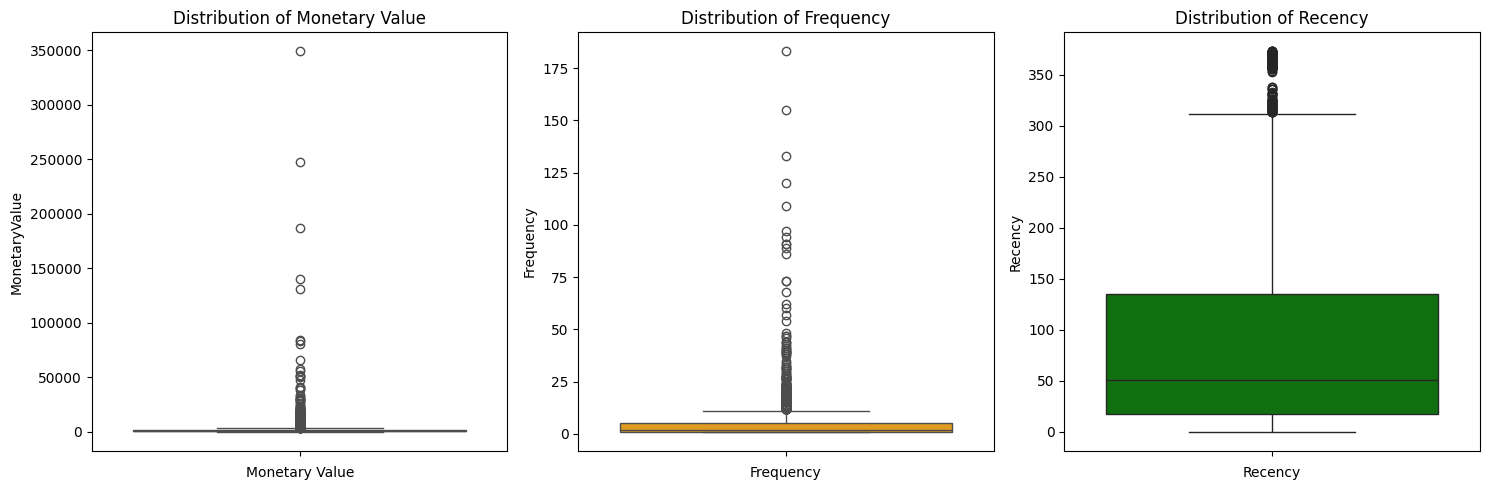

In [26]:
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
sns.boxplot(data=aggregated_df['MonetaryValue'], color='blue')
plt.title('Distribution of Monetary Value')
plt.xlabel('Monetary Value')

plt.subplot(1, 3, 2)
sns.boxplot(data=aggregated_df['Frequency'], color='orange')
plt.title('Distribution of Frequency')
plt.xlabel('Frequency')

plt.subplot(1, 3, 3)
sns.boxplot(data=aggregated_df['Recency'], color='green')
plt.title('Distribution of Recency')
plt.xlabel('Recency')

plt.tight_layout()
plt.show()

In [27]:
M_Q1 = aggregated_df['MonetaryValue'].quantile(0.25)
M_Q3 = aggregated_df['MonetaryValue'].quantile(0.75)
M_IQR = M_Q3 - M_Q1
M_upper_bound = M_Q3 + 1.5 * M_IQR
M_lower_bound = M_Q1 - 1.5 * M_IQR
M_outliers_df = aggregated_df[(aggregated_df['MonetaryValue'] > M_upper_bound) | (aggregated_df['MonetaryValue'] < M_lower_bound)]

M_outliers_df.describe()

,Customer ID,MonetaryValue,Frequency,LastPurchase,Recency
count,423.000000,423.000000,423.000000,423,423.000000
mean,15103.040189,12188.101726,17.167849,2010-11-09 12:26:02.978723328,30.035461
min,12357.000000,3802.040000,1.000000,2009-12-10 18:03:00,0.000000
25%,13622.000000,4605.940000,8.000000,2010-11-08 13:17:30,3.000000
50%,14961.000000,6191.320000,12.000000,2010-11-26 12:19:00,13.000000
75%,16692.000000,10273.235000,18.000000,2010-12-06 10:34:30,31.000000
max,18260.000000,349164.350000,183.000000,2010-12-09 19:32:00,364.000000
std,1728.661406,25830.851044,19.729755,NaN,51.541004


In [28]:
F_Q1 = aggregated_df['Frequency'].quantile(0.25)
F_Q3 = aggregated_df['Frequency'].quantile(0.75)
F_IQR = F_Q3 - F_Q1
F_upper_bound = F_Q3 + 1.5 * F_IQR
F_lower_bound = F_Q1 - 1.5 * F_IQR
F_outliers = aggregated_df[(aggregated_df['Frequency'] > F_upper_bound) | (aggregated_df['Frequency'] < F_lower_bound)]

F_outliers.describe()

,Customer ID,MonetaryValue,Frequency,LastPurchase,Recency
count,279.000000,279.000000,279.000000,279,279.000000
mean,15352.655914,14409.714910,23.810036,2010-11-23 11:06:20.645161216,16.089606
min,12437.000000,1094.390000,12.000000,2010-05-12 16:51:00,0.000000
25%,13800.000000,4331.560000,13.000000,2010-11-20 13:14:30,2.000000
50%,15465.000000,6615.770000,17.000000,2010-12-02 10:46:00,7.000000
75%,16828.500000,11692.405000,23.000000,2010-12-07 11:08:30,19.000000
max,18260.000000,349164.350000,183.000000,2010-12-09 19:32:00,211.000000
std,1748.429987,31381.736785,21.932937,NaN,26.589117


In [29]:
non_outliers_df = aggregated_df[(~aggregated_df.index.isin(M_outliers_df.index)) & (~aggregated_df.index.isin(F_outliers.index))]
non_outliers_df.describe()

,Customer ID,MonetaryValue,Frequency,LastPurchase,Recency
count,3809.000000,3809.000000,3809.000000,3809,3809.000000
mean,15376.482804,885.502195,2.863481,2010-09-03 11:16:46.516146176,97.082174
min,12346.000000,1.550000,1.000000,2009-12-01 10:49:00,0.000000
25%,13912.000000,279.910000,1.000000,2010-07-08 14:48:00,22.000000
50%,15389.000000,588.050000,2.000000,2010-10-12 16:25:00,58.000000
75%,16854.000000,1269.050000,4.000000,2010-11-17 13:14:00,154.000000
max,18287.000000,3788.210000,11.000000,2010-12-09 20:01:00,373.000000
std,1693.199806,817.672280,2.243748,NaN,98.111495


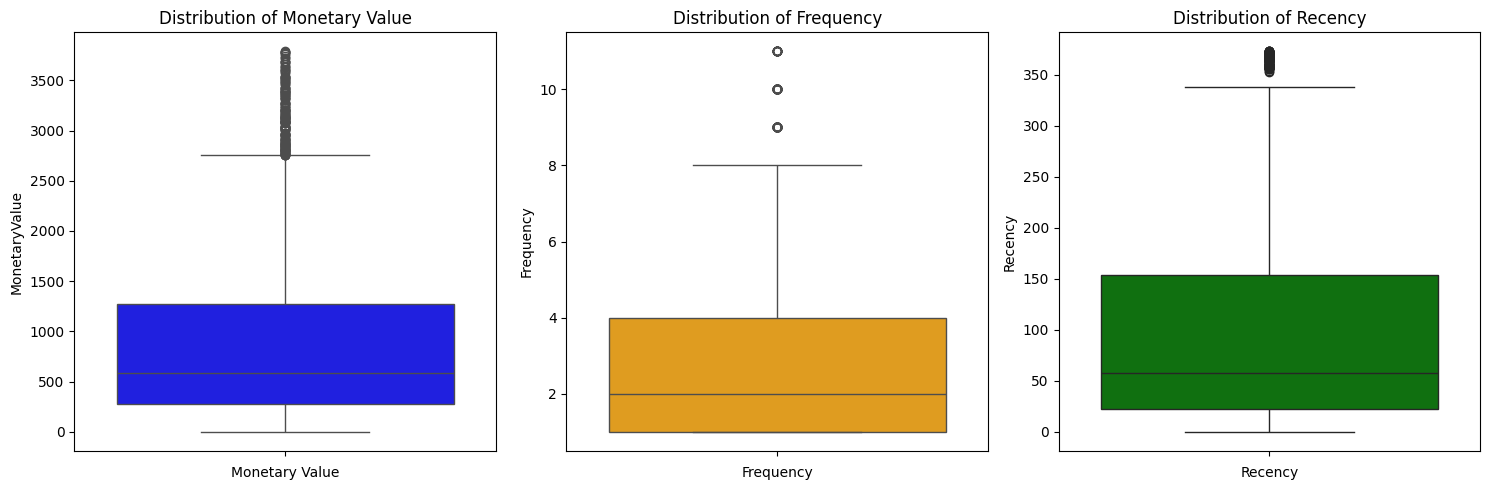

In [30]:
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
sns.boxplot(data=non_outliers_df['MonetaryValue'], color='blue')
plt.title('Distribution of Monetary Value')
plt.xlabel('Monetary Value')

plt.subplot(1, 3, 2)
sns.boxplot(data=non_outliers_df['Frequency'], color='orange')
plt.title('Distribution of Frequency')
plt.xlabel('Frequency')

plt.subplot(1, 3, 3)
sns.boxplot(data=non_outliers_df['Recency'], color='green')
plt.title('Distribution of Recency')
plt.xlabel('Recency')

plt.tight_layout()
plt.show()

Text(0.5, 0.92, '3D Scatter Plot of Customer Data')

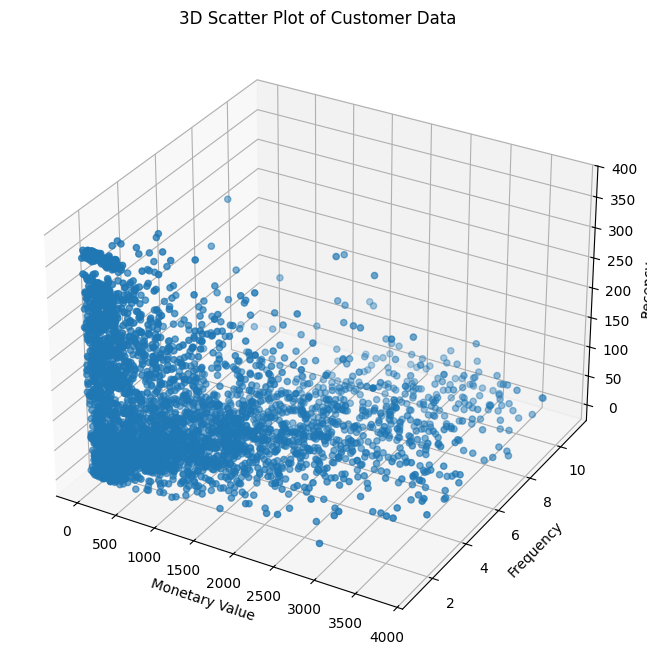

In [31]:
fig = plt.figure(figsize=(8, 8))

ax = fig.add_subplot(projection='3d')

scatter = ax.scatter(non_outliers_df['MonetaryValue'], non_outliers_df['Frequency'], non_outliers_df['Recency'])
ax.set_xlabel('Monetary Value')
ax.set_ylabel('Frequency')
ax.set_zlabel('Recency')
ax.set_title('3D Scatter Plot of Customer Data')

In [32]:
# Normalization
scaler = StandardScaler()
scaled_data = scaler.fit_transform(non_outliers_df[['MonetaryValue', 'Frequency', 'Recency']])

scaled_data

array([[-0.87594534, -0.38488934,  0.68214853],
       [ 0.53551441, -0.38488934, -0.96925093],
       [-0.81258645, -0.83063076, -0.24548944],
       ...,
       [-0.62197163, -0.83063076,  2.01753946],
       [ 0.44146683, -0.38488934,  0.14187587],
       [ 1.72488782,  0.50659348, -0.81634357]])

In [33]:
scaled_data_df = pd.DataFrame(scaled_data, columns=['MonetaryValue', 'Frequency', 'Recency'], index=non_outliers_df.index)
scaled_data_df

,MonetaryValue,Frequency,Recency
0,-0.875945,-0.384889,0.682149
1,0.535514,-0.384889,-0.969251
2,-0.812586,-0.830631,-0.245489
3,1.633678,-0.384889,-0.561498
4,-0.715016,-0.830631,-0.887700
...,...,...,...
4280,-0.298120,1.398076,-0.816344
4281,-0.579553,-0.830631,-0.316846
4282,-0.621972,-0.830631,2.017539
4283,0.441467,-0.384889,0.141876


Text(0.5, 0.92, '3D Scatter Plot of Customer Data')

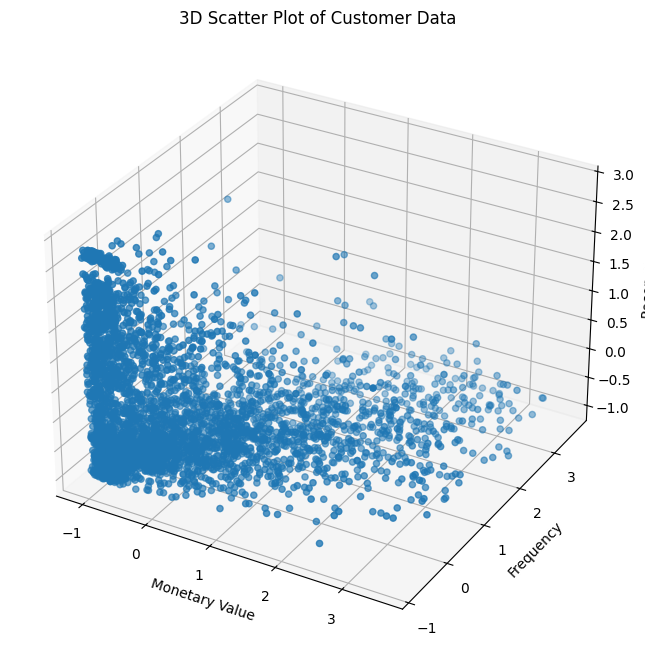

In [34]:
fig = plt.figure(figsize=(8, 8))

ax = fig.add_subplot(projection='3d')

scatter = ax.scatter(scaled_data_df['MonetaryValue'], scaled_data_df['Frequency'], scaled_data_df['Recency'])
ax.set_xlabel('Monetary Value')
ax.set_ylabel('Frequency')
ax.set_zlabel('Recency')
ax.set_title('3D Scatter Plot of Customer Data')

**Clustering**

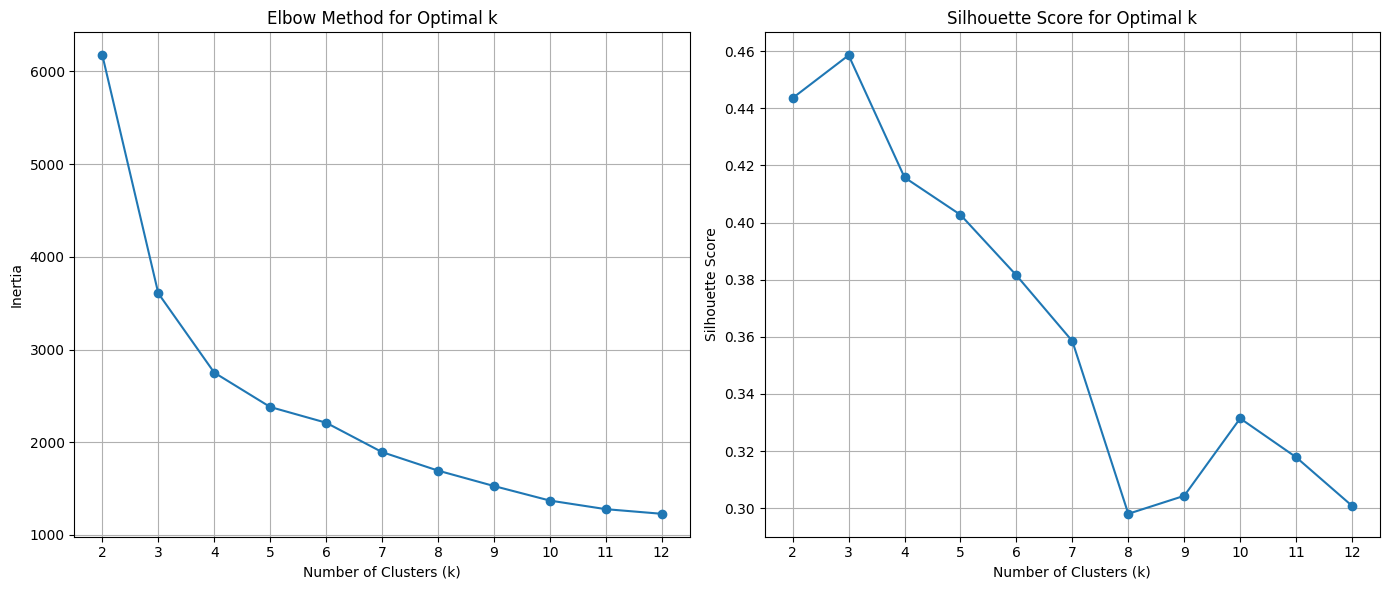

In [35]:
max_k = 12
inertia = []
k_values = range(2, max_k + 1)
silhouette_scores = []

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42, max_iter=1000)
    cluster_labels = kmeans.fit_predict(scaled_data_df)
    
    silhouette_avg = silhouette_score(scaled_data_df, cluster_labels)
    silhouette_scores.append(silhouette_avg)
    
    inertia.append(kmeans.inertia_)
    
plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
plt.plot(k_values, inertia, marker='o')
plt.title('Elbow Method for Optimal k')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.xticks(k_values)
plt.grid()

plt.subplot(1, 2, 2)
plt.plot(k_values, silhouette_scores, marker='o')
plt.title('Silhouette Score for Optimal k')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Silhouette Score')
plt.xticks(k_values)
plt.grid()

plt.tight_layout()
plt.show()

In [36]:
kmeans = KMeans(n_clusters=4, random_state=42, max_iter=1000)

cluster_labels = kmeans.fit_predict(scaled_data_df)

In [37]:
non_outliers_df['Cluster'] = cluster_labels

non_outliers_df

C:\Users\ASUS\AppData\Local\Temp\ipykernel_11476\1791966522.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  non_outliers_df['Cluster'] = cluster_labels


,Customer ID,MonetaryValue,Frequency,LastPurchase,Recency,Cluster
0,12346.0,169.36,2,2010-06-28 13:53:00,164,1
1,12347.0,1323.32,2,2010-12-07 14:57:00,2,0
2,12348.0,221.16,1,2010-09-27 14:59:00,73,2
3,12349.0,2221.14,2,2010-10-28 08:23:00,42,0
4,12351.0,300.93,1,2010-11-29 15:23:00,10,2
...,...,...,...,...,...,...
4280,18283.0,641.77,6,2010-11-22 15:30:00,17,0
4281,18284.0,411.68,1,2010-10-04 11:33:00,66,2
4282,18285.0,377.00,1,2010-02-17 10:24:00,295,1
4283,18286.0,1246.43,2,2010-08-20 11:57:00,111,0


Text(0.5, 0.92, '3D Scatter Plot of Customer Data')

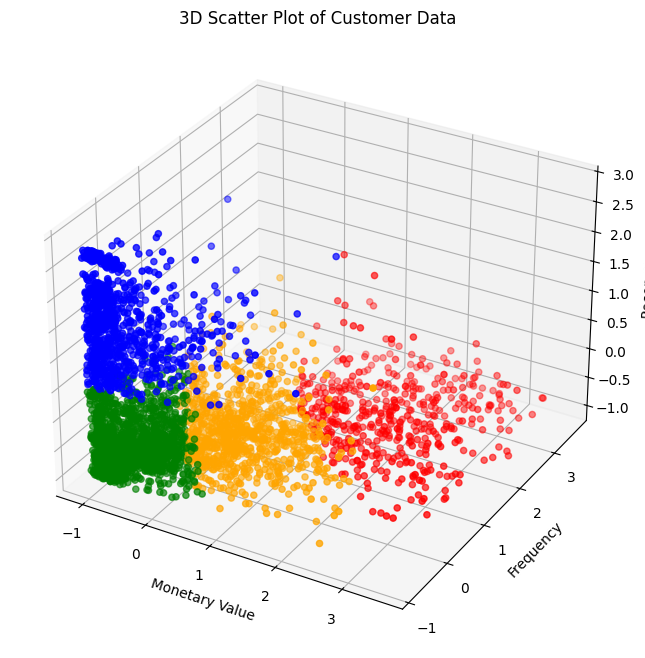

In [38]:
cluster_colors = {0: 'orange', 1: 'blue', 2: 'green', 3: 'red'}
colors = non_outliers_df['Cluster'].map(cluster_colors)

fig = plt.figure(figsize=(8, 8))
ax = fig.add_subplot(projection='3d')

scatter = ax.scatter(scaled_data_df['MonetaryValue'], scaled_data_df['Frequency'], scaled_data_df['Recency'], c=colors)
ax.set_xlabel('Monetary Value')
ax.set_ylabel('Frequency')
ax.set_zlabel('Recency')
ax.set_title('3D Scatter Plot of Customer Data')

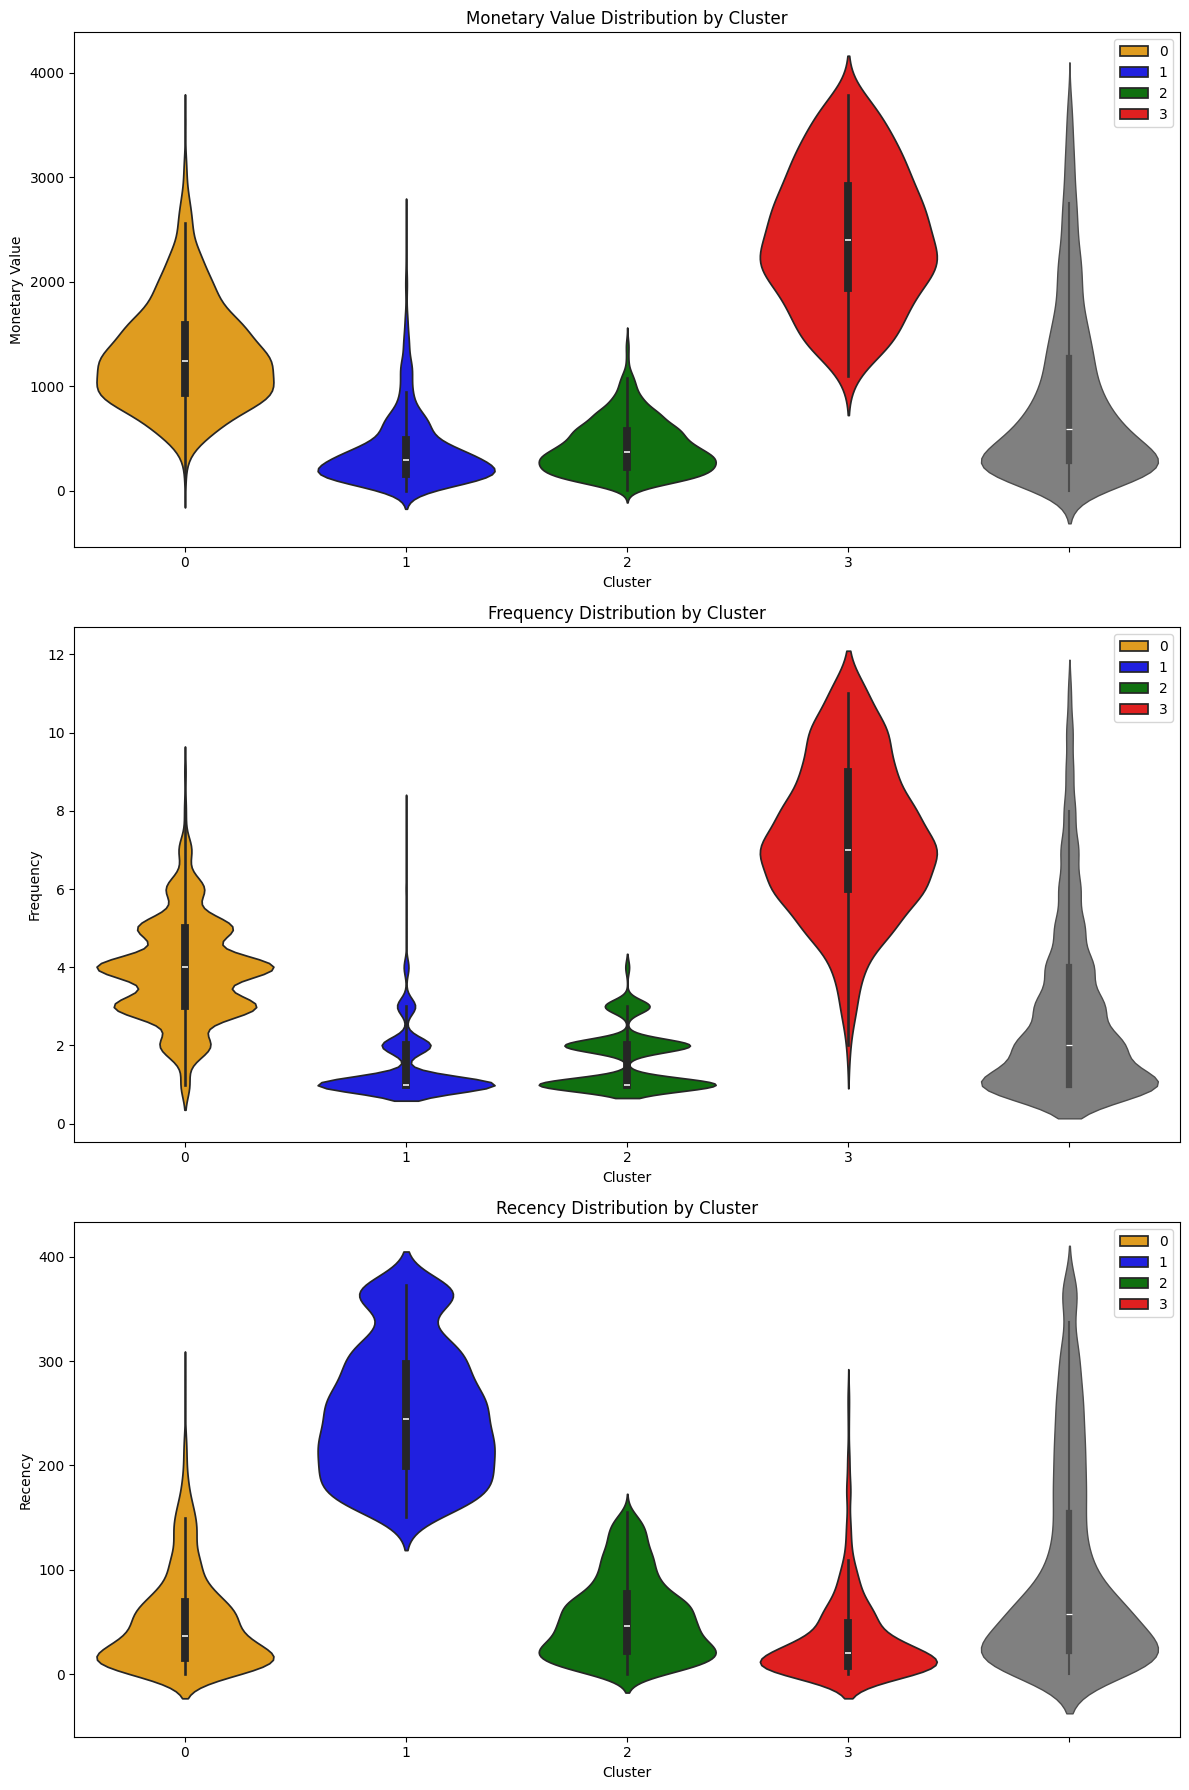

In [39]:
plt.figure(figsize=(12, 18))

plt.subplot(3, 1, 1)
sns.violinplot(x=non_outliers_df['Cluster'], y=non_outliers_df['MonetaryValue'], palette=cluster_colors, hue=non_outliers_df['Cluster'])
sns.violinplot(y='MonetaryValue', data=non_outliers_df, color='gray', linewidth=1.0)
plt.title('Monetary Value Distribution by Cluster')
plt.ylabel('Monetary Value')

plt.subplot(3, 1, 2)
sns.violinplot(x=non_outliers_df['Cluster'], y=non_outliers_df['Frequency'], data=non_outliers_df, palette=cluster_colors, hue=non_outliers_df['Cluster'])
sns.violinplot(y='Frequency', data=non_outliers_df, color='gray', linewidth=1.0)
plt.title('Frequency Distribution by Cluster')
plt.ylabel('Frequency')

plt.subplot(3, 1, 3)
sns.violinplot(x=non_outliers_df['Cluster'], y=non_outliers_df['Recency'], data=non_outliers_df, palette=cluster_colors, hue=non_outliers_df['Cluster'])
sns.violinplot(y='Recency', data=non_outliers_df, color='gray', linewidth=1.0)
plt.title('Recency Distribution by Cluster')
plt.ylabel('Recency')

plt.tight_layout()
plt.show()

◇ Cluster 0 (Yellow): "Retain"
- Recency(Low), Frequency(Mid), Monetary(Mid)
- **Behavior** : They buy consistently and spend a healthy amount, but haven't quite reached the elite spending or frequency levels.
- **Action** : Focus on increasing their average order value (AOV). Recommend higher-tier products, offer bundled deals, and use personalized cross-selling campaigns

◇ Cluster 1 (Blue): "Revive"
- Recency(Very High), Frequency(Very Low), Monetary(Very Low)
- **Behavior** : They bought a long time ago, only bought once or twice, and spent very little. They have effectively left your business.
- **Action** : Run a low-cost, automated win-back campaign with a strong, one-time discount to see if they can be woken up. If they don't engage, scrub them from your active mailing list to protect your engagement rates and save marketing costs.

◇ Cluster 2 (Green): "Nurture"
- Recency(Very Low), Frequency(Low), Monetary(Low)
- **Behavior** : They just made their first (or second) purchase. They haven't spent much yet and haven't built a habit with your brand.
- **Action** : Make them feel welcomed and valued immediately. Send onboarding sequences, brand story emails, or a time-sensitive discount for their next purchase to build a buying habit before they forget about you.

◇ Cluster 3 (Red): "Rewards"
- Recency(Very Low), Frequency(Very High), Monetary(Very High)
- **Behavior** : They bought very recently, buy the most frequently, and spend the most money. They are the core drivers of your revenue.
- **Action** : Invite them to VIP programs, give them early access to new products, and leverage them for reviews or referrals. Avoid giving them deep discounts, as they are already highly willing to buy.

**Outliers Analysis**

In [40]:
overlap_indeces = M_outliers_df.index.intersection(F_outliers.index)

M_only_outliers = M_outliers_df[~M_outliers_df.index.isin(overlap_indeces)]
F_only_outliers = F_outliers[~F_outliers.index.isin(overlap_indeces)]
MnF_outliers = M_outliers_df.loc[overlap_indeces]

M_only_outliers['Cluster'] = -1
F_only_outliers['Cluster'] = -2
MnF_outliers['Cluster'] = -3

outliers_clusters_df = pd.concat([M_only_outliers, F_only_outliers, MnF_outliers])
outliers_clusters_df

C:\Users\ASUS\AppData\Local\Temp\ipykernel_11476\3540453185.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  M_only_outliers['Cluster'] = -1
C:\Users\ASUS\AppData\Local\Temp\ipykernel_11476\3540453185.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  F_only_outliers['Cluster'] = -2


,Customer ID,MonetaryValue,Frequency,LastPurchase,Recency,Cluster
9,12357.0,11229.99,1,2010-11-16 10:05:00,23,-1
25,12380.0,4782.84,4,2010-08-31 14:54:00,100,-1
42,12409.0,12346.62,4,2010-10-15 10:24:00,55,-1
48,12415.0,19468.84,4,2010-11-29 15:07:00,10,-1
61,12431.0,4145.52,11,2010-12-01 10:03:00,8,-1
...,...,...,...,...,...,...
4235,18223.0,7516.31,12,2010-11-17 12:20:00,22,-3
4236,18225.0,7545.14,15,2010-12-09 15:46:00,0,-3
4237,18226.0,6650.83,15,2010-11-26 15:51:00,13,-3
4241,18231.0,4791.80,23,2010-10-29 14:17:00,41,-3


Text(0.5, 0.92, '3D Scatter Plot of Customer Data')

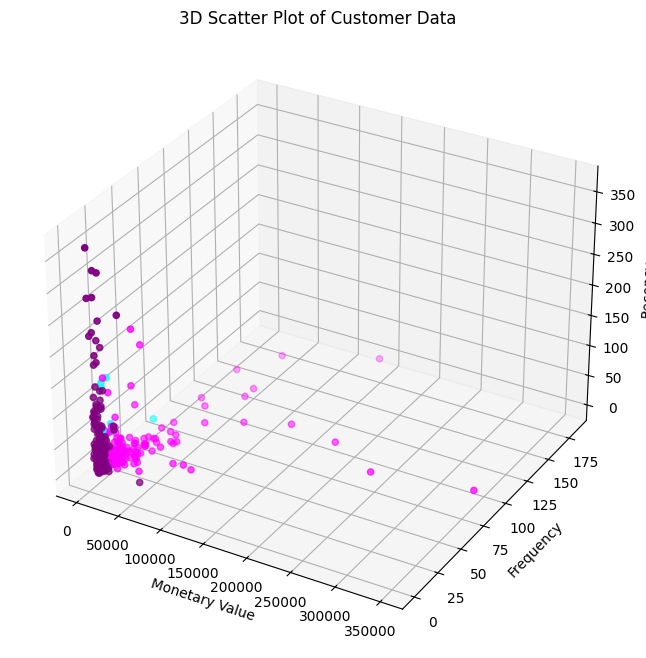

In [41]:
cluster_colors = {-1: 'purple', -2: 'cyan', -3: 'magenta'}
colors = outliers_clusters_df['Cluster'].map(cluster_colors)

fig = plt.figure(figsize=(8, 8))
ax = fig.add_subplot(projection='3d')

scatter = ax.scatter(outliers_clusters_df['MonetaryValue'], outliers_clusters_df['Frequency'], outliers_clusters_df['Recency'], c=colors)
ax.set_xlabel('Monetary Value')
ax.set_ylabel('Frequency')
ax.set_zlabel('Recency')
ax.set_title('3D Scatter Plot of Customer Data')

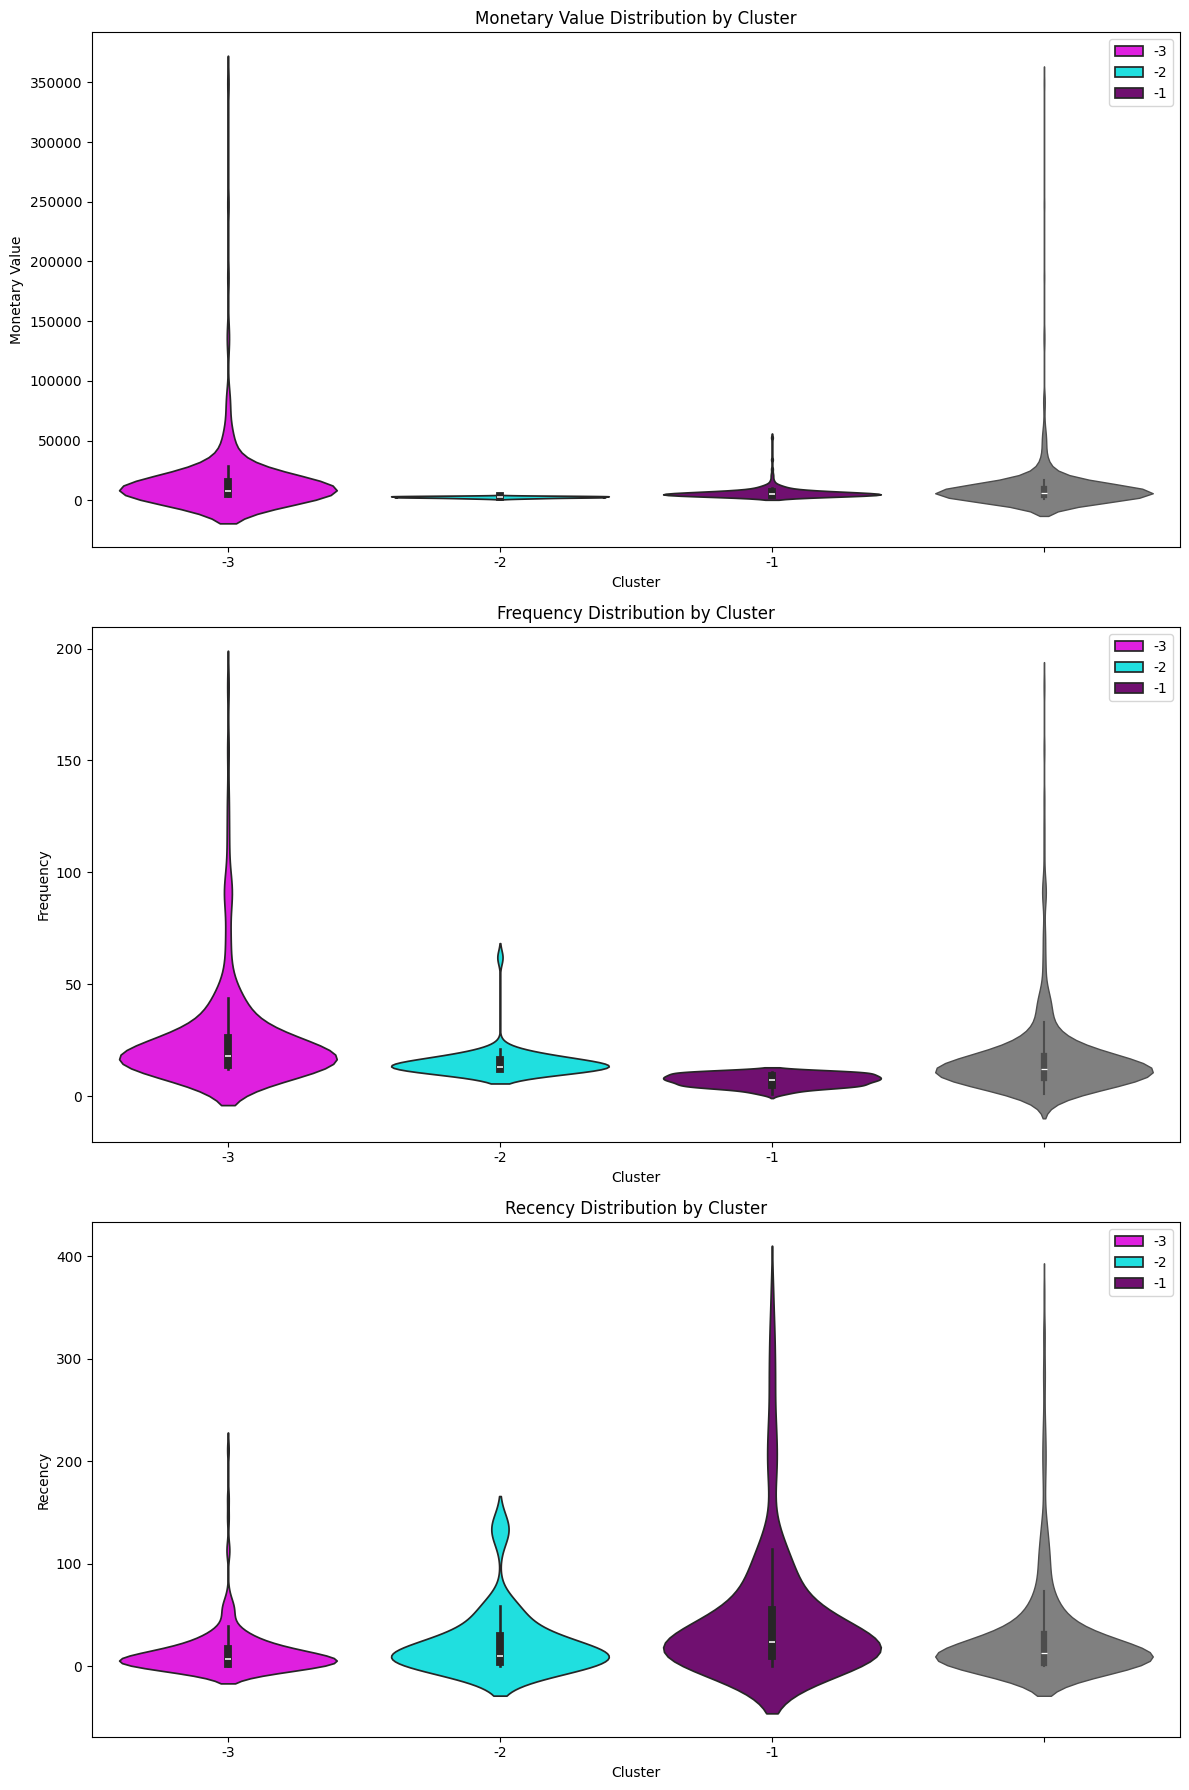

In [42]:
cluster_colors = {-1: 'purple', -2: 'cyan', -3: 'magenta'}

plt.figure(figsize=(12, 18))

plt.subplot(3, 1, 1)
sns.violinplot(x=outliers_clusters_df['Cluster'], y=outliers_clusters_df['MonetaryValue'], palette=cluster_colors, hue=outliers_clusters_df['Cluster'])
sns.violinplot(y='MonetaryValue', data=outliers_clusters_df, color='gray', linewidth=1.0)
plt.title('Monetary Value Distribution by Cluster')
plt.ylabel('Monetary Value')

plt.subplot(3, 1, 2)
sns.violinplot(x=outliers_clusters_df['Cluster'], y=outliers_clusters_df['Frequency'], data=outliers_clusters_df, palette=cluster_colors, hue=outliers_clusters_df['Cluster'])
sns.violinplot(y='Frequency', data=outliers_clusters_df, color='gray', linewidth=1.0)
plt.title('Frequency Distribution by Cluster')
plt.ylabel('Frequency')

plt.subplot(3, 1, 3)
sns.violinplot(x=outliers_clusters_df['Cluster'], y=outliers_clusters_df['Recency'], data=outliers_clusters_df, palette=cluster_colors, hue=outliers_clusters_df['Cluster'])
sns.violinplot(y='Recency', data=outliers_clusters_df, color='gray', linewidth=1.0)
plt.title('Recency Distribution by Cluster')
plt.ylabel('Recency')

plt.tight_layout()
plt.show()

◇ Cluster -3 (Magenta): "Pamper"
- Recency(Very Low), Frequency(Extremly High), Monetary(Extremly High)
- **Behavior** : The absolute top tier. These are your most extreme outliers who generate a massive portion of your revenue. They buy incredibly often and spend astronomical amounts.
- **Action** : Standard marketing does not apply here. Assign them dedicated account managers, offer white-glove customer service, invite them to exclusive offline events, and completely eliminate any friction in their purchasing process.

◇ Cluster -2 (Cyan): "Facilitate"
- Recency(Low), Frequency(High), Monetary(Low to Mid)
- **Behavior** : These customers buy constantly. They might be smaller B2B resellers, corporate buyers, or simply die-hard fans who make frequent, smaller purchases.
- **Action** : Since they buy so often, focus on convenience. Offer them subscription models, bulk-buy discounts, or "fast-lane" checkout options. Reward their extreme frequency with a tiered loyalty program.

◇ Cluster -1 (Purple): "Rescue"
- Recency(Very Low), Frequency(Mid), Monetary(Mid)
- **Behavior** : This is a volatile group of high-value customers. They have solid historical spending and frequency, but their recency is extremely erratic—some are active, but a massive tail stretches all the way to 400 days, indicating many of these high-value buyers have stopped purchasing.
- **Action** : Must prevent these high-value users from completely churning. Set up automated triggers: the moment a "Rescue" goes beyond 60 days without a purchase, hit them with a highly personalized, aggressive VIP win-back offer. Do not let them slip away.

In [48]:
cluster_labels = {
    0: 'Retain',
    1: 'Revive',
    2: 'Nurture',
    3: 'Rewards',
    -1: 'Rescue',
    -2: 'Facilitate',
    -3: 'Pamper'
}

In [49]:
full_clusters_df = pd.concat([non_outliers_df, outliers_clusters_df])
full_clusters_df

,Customer ID,MonetaryValue,Frequency,LastPurchase,Recency,Cluster
0,12346.0,169.36,2,2010-06-28 13:53:00,164,1
1,12347.0,1323.32,2,2010-12-07 14:57:00,2,0
2,12348.0,221.16,1,2010-09-27 14:59:00,73,2
3,12349.0,2221.14,2,2010-10-28 08:23:00,42,0
4,12351.0,300.93,1,2010-11-29 15:23:00,10,2
...,...,...,...,...,...,...
4235,18223.0,7516.31,12,2010-11-17 12:20:00,22,-3
4236,18225.0,7545.14,15,2010-12-09 15:46:00,0,-3
4237,18226.0,6650.83,15,2010-11-26 15:51:00,13,-3
4241,18231.0,4791.80,23,2010-10-29 14:17:00,41,-3


In [50]:
full_clusters_df['Cluster'] = full_clusters_df['Cluster'].map(cluster_labels)
full_clusters_df

,Customer ID,MonetaryValue,Frequency,LastPurchase,Recency,Cluster
0,12346.0,169.36,2,2010-06-28 13:53:00,164,Revive
1,12347.0,1323.32,2,2010-12-07 14:57:00,2,Retain
2,12348.0,221.16,1,2010-09-27 14:59:00,73,Nurture
3,12349.0,2221.14,2,2010-10-28 08:23:00,42,Retain
4,12351.0,300.93,1,2010-11-29 15:23:00,10,Nurture
...,...,...,...,...,...,...
4235,18223.0,7516.31,12,2010-11-17 12:20:00,22,Pamper
4236,18225.0,7545.14,15,2010-12-09 15:46:00,0,Pamper
4237,18226.0,6650.83,15,2010-11-26 15:51:00,13,Pamper
4241,18231.0,4791.80,23,2010-10-29 14:17:00,41,Pamper


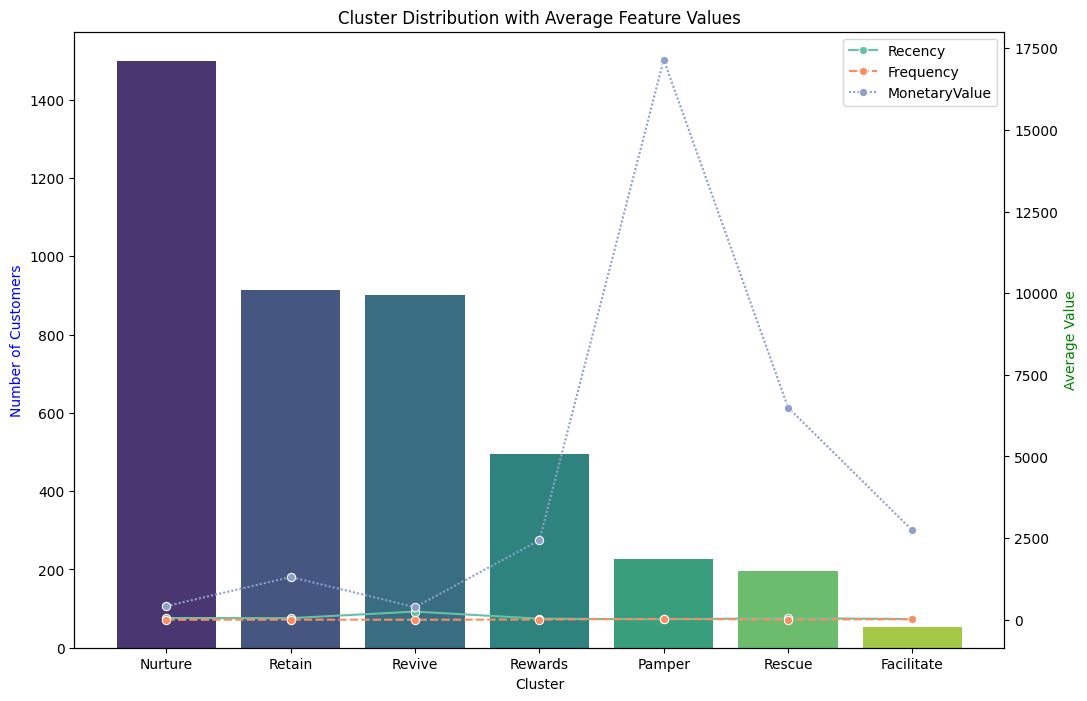

In [51]:
cluster_counts = full_clusters_df['Cluster'].value_counts()
feature_means = full_clusters_df.groupby('Cluster')[['Recency', 'Frequency', 'MonetaryValue']].mean()

fig, ax1 = plt.subplots(figsize=(12, 8))

sns.barplot(x=cluster_counts.index, y=cluster_counts.values, ax=ax1, palette='viridis', hue=cluster_counts.index)
ax1.set_ylabel('Number of Customers', color='b')
ax1.set_title('Cluster Distribution with Average Feature Values')

ax2 = ax1.twinx()

sns.lineplot(data=feature_means, ax=ax2, palette='Set2', marker='o')
ax2.set_ylabel('Average Value', color='g')

plt.show()

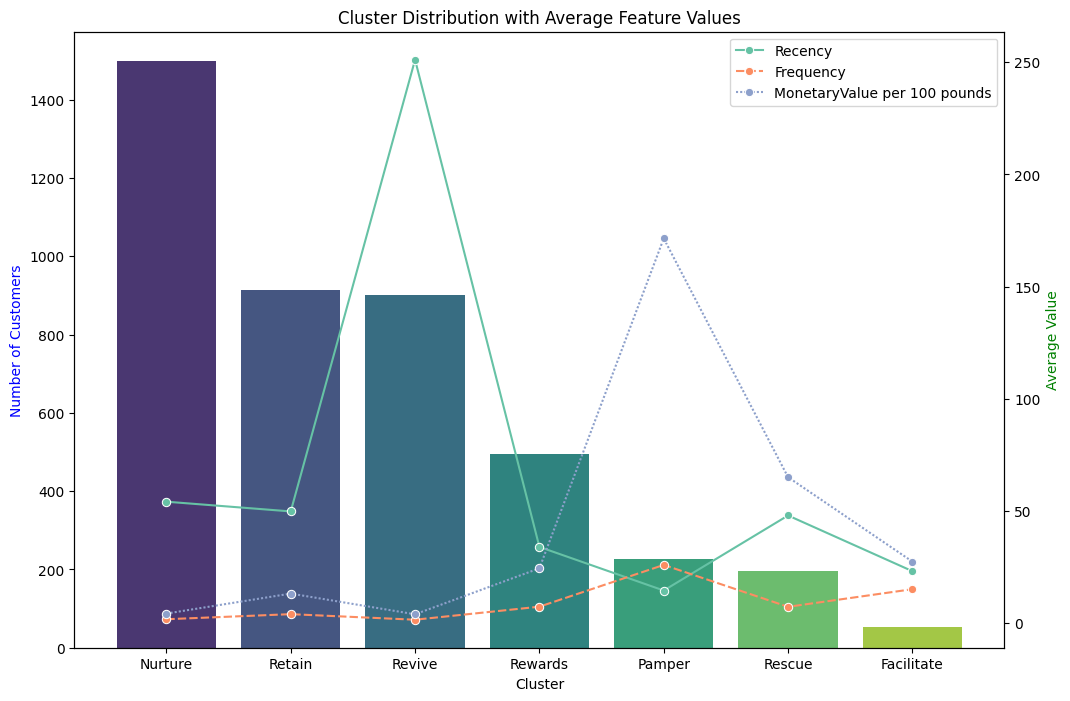

In [52]:
cluster_counts = full_clusters_df['Cluster'].value_counts()
full_clusters_df["MonetaryValue per 100 pounds"] = full_clusters_df["MonetaryValue"] / 100.00
feature_means = full_clusters_df.groupby('Cluster')[['Recency', 'Frequency', 'MonetaryValue per 100 pounds']].mean()

fig, ax1 = plt.subplots(figsize=(12, 8))

sns.barplot(x=cluster_counts.index, y=cluster_counts.values, ax=ax1, palette='viridis', hue=cluster_counts.index)
ax1.set_ylabel('Number of Customers', color='b')
ax1.set_title('Cluster Distribution with Average Feature Values')

ax2 = ax1.twinx()

sns.lineplot(data=feature_means, ax=ax2, palette='Set2', marker='o')
ax2.set_ylabel('Average Value', color='g')

plt.show()